In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import find_peaks, peak_widths

import waveguide_solver as wgs

In [25]:
# Example of parabolic density profile
r_ch = 35e-6  # Channel radius (m)
r_cutoff = 70e-6  # Density cutoff radius (m)
shock_flat = 10e-6  # Shock transition width (m)
shock_taper = 10e-6  # Shock taper width (m)
n_e0 = 1e23   # On-axis density (m^-3)
delta_ne = 1e23  # Density difference (m^-3)
lam = 815e-9 # wavelength (m)
n_cr = wgs.critical_density(lam)  # Critical density for 800 nm light
m = 2

r = np.linspace(1e-6, 1000e-6, 1000)  # Radial grid (m)
n_e = wgs.truncated_parabolic_channel(r, r_ch, r_cutoff, shock_flat, shock_taper, n_e0, delta_ne)
k0 = 2 * np.pi / lam  # Free space wavenumber (m^-1)
beta_arr = np.linspace(0.9992, 1, 1000) * k0

beta_modes, eta_modes, beta_all, eta_all = wgs.find_eigenmodes(r, k0, beta_arr, n_e, n_cr, m=m)

Performing initial coarse scan over beta values...


Calculating eta for beta values: 100%|██████████| 1000/1000 [03:19<00:00,  5.02it/s]


[74.03318981 61.53449135 38.89427375 13.52005301  1.27743506]
Found unresolved peaks at beta/k0 = [0.99988468], refining scan around these peaks...


Calculating eta for beta values: 100%|██████████| 12/12 [00:01<00:00,  9.02it/s]


[74.03318981 61.53449135 38.89427375 13.52005301  5.08683024]
Found unresolved peaks at beta/k0 = [0.99988447], refining scan around these peaks...


Calculating eta for beta values: 100%|██████████| 12/12 [00:01<00:00, 10.06it/s]

[74.03318981 61.53449135 38.89427375 13.52005301 15.96127793]


(0.0, 63.86776566614728)

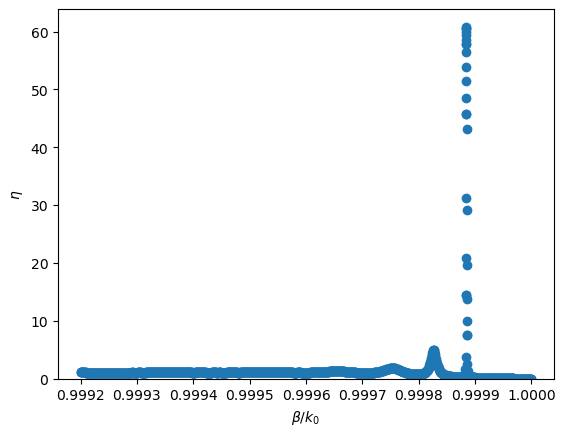

In [26]:
fig, ax = plt.subplots()
ax.scatter(beta_all / k0, eta_all)
ax.set_xlabel(r'$\beta / k_0$')
ax.set_ylabel(r'$\eta$')
# ax.set_xlim(0.99994150, 0.99994160)
ax.set_ylim(bottom=0)

Fundamental mode beta: 0.999885 m^-1


(0.0, 200.0)

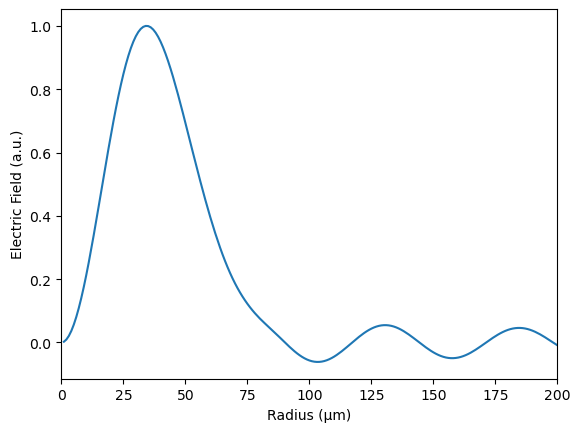

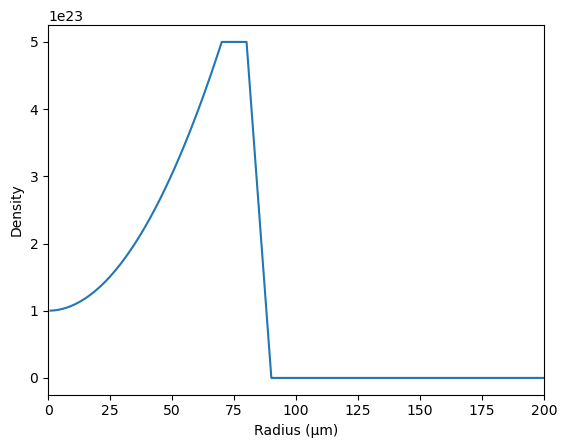

In [27]:
# Find the fundamental mode of the channel by looking for the maximum eta
max_eta_index = np.argmax(eta_all)
beta_fundamental = beta_all[max_eta_index]
print(f"Fundamental mode beta: {beta_fundamental/k0:.6f} m^-1")

kappa2 = wgs.transverse_wavenumber(n_e, n_cr, k0, beta_fundamental)
mode_00 = wgs.solve_waveguide_fundamental_ivp(r, kappa2, m=m)

fig, ax = plt.subplots()
ax.plot(r * 1e6, mode_00, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Electric Field (a.u.)')
ax.set_xlim(0, 200)

fig, ax = plt.subplots()
ax.plot(r * 1e6, n_e, label='Fundamental Mode')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Density')
ax.set_xlim(0, 200)

[424 567 690 782 867]
Peak at beta/k0 = 0.999540 with eta = 1.1712
Peak at beta/k0 = 0.999654 with eta = 1.3237
Peak at beta/k0 = 0.999753 with eta = 1.8436
Peak at beta/k0 = 0.999826 with eta = 4.9955
Peak at beta/k0 = 0.999885 with eta = 60.8264


(0.0, 150.0)

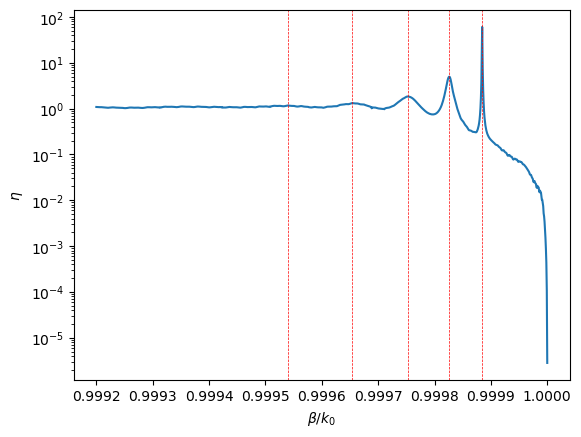

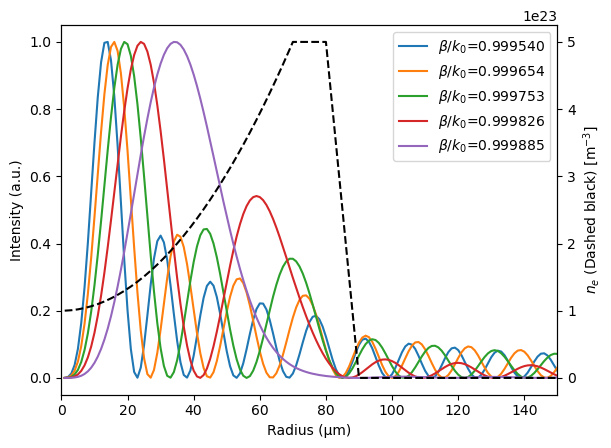

In [28]:
peaks, properties = find_peaks(eta_all, prominence=0.1)
print(peaks)
for p in peaks:
    print(f"Peak at beta/k0 = {beta_all[p]/k0:.6f} with eta = {eta_all[p]:.4f}")

fig, ax = plt.subplots()

ax.plot(beta_all / k0, eta_all)
ax.set_yscale("log")
ax.set_xlabel(r'$\beta / k_0$')
ax.set_ylabel(r'$\eta$')
for p in peaks:
    ax.axvline(beta_all[p] / k0, color='red', linestyle='dashed', linewidth=0.5, label=f'Peak at beta/k0={beta_all[p]/k0:.6f}')

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax2.plot(r * 1e6, n_e, linestyle="dashed", color="black")
ax2.set_ylabel(r"$n_e$ (Dashed black) [m$^{-3}$]", color="black")

for p in peaks:
    beta = beta_all[p]
    kappa2 = wgs.transverse_wavenumber(n_e, n_cr, k0, beta)
    mode = wgs.solve_waveguide_fundamental_ivp(r, kappa2, m=m)
    ax.plot(r * 1e6, mode**2, label=f'$\\beta/k_0$={beta/k0:.6f}')
ax.set_xlabel('Radius (µm)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
ax.set_xlim(0, 150)

In [29]:
# Calculate attenuation lengths for each peak
widths_1_m = wgs.calculate_L_att(beta_all, eta_all)
print(peaks)

for p, width_1_m in zip(peaks, widths_1_m):
    print(f"Attenuation length for peak at beta/k0={beta_all[p]/k0:.6f}: {width_1_m:.2e} m")


[424 567 690 782 867]
Attenuation length for peak at beta/k0=0.999540: 2.19e-03 m
Attenuation length for peak at beta/k0=0.999654: 2.63e-03 m
Attenuation length for peak at beta/k0=0.999753: 4.16e-03 m
Attenuation length for peak at beta/k0=0.999826: 1.20e-02 m
Attenuation length for peak at beta/k0=0.999885: 1.80e-01 m
